# Closed-Loop vs. Decomposed Go-to-Goal Control Under Actuation Noise

**Research Track II -- Final Assignment, Experimental Notebook**
Mohamed Tawakol -- University of Genoa

---

## Research question

> *Does a proportional closed-loop go-to-goal controller improve time-to-goal and
> path efficiency, compared to a rotate-then-translate baseline, for a unicycle
> mobile robot under increasing actuation noise?*

## Hypotheses (stated before data analysis)

- **H1** -- The proportional controller reaches the goal faster (lower time-to-goal)
  than the rotate-then-translate baseline at every noise level.
- **H2** -- The rotate-then-translate baseline has higher path efficiency than the
  proportional controller in the noise-free case (it moves along a straight line
  after aligning), but its efficiency degrades faster as actuation noise grows.
- **H3** -- The advantage of the proportional controller in time-to-goal increases
  with the noise level (interaction effect), because heading errors are corrected
  continuously instead of triggering full stop-and-rotate phases.

## Experimental design

| | |
|---|---|
| Independent variables | controller in {proportional, rotate_translate}; noise level in {0.0, 0.1, 0.3} |
| Dependent variables (metrics) | time-to-goal [s], path length [m], path efficiency [0-1], success rate |
| Control variables | arena (11x11), start pose (5.5, 5.5, 0), velocity limits (2 m/s, 2 rad/s), dt = 0.05 s, timeout 60 s, goal tolerance 0.15 m, controller gains |
| Design | 2x3 full factorial, N = 25 paired trials per condition (same seeds -> same goals and noise schedule across controllers) |

The experiment is executed by the ROS2 node `goal_nav_experiment/experiment_node`,
which simulates a unicycle robot with additive Gaussian actuation noise and returns
the metrics of each trial. This notebook talks to the node over the
`/experiment/run` and `/experiment/result` topics (JSON payloads), aggregates the
data, and produces the plots and statistical tests used in the paper.


## 1. Imports and global configuration

In [1]:
import json
import os
import subprocess
import threading
import time
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import rclpy
from rclpy.node import Node
from std_msgs.msg import String

import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

# experiment configuration (must match the paper)
CONTROLLERS = ['proportional', 'rotate_translate']
NOISE_LEVELS = [0.0, 0.1, 0.3]
N_TRIALS = 25          # paired trials per condition
SEEDS = list(range(N_TRIALS))

DATA_DIR = os.path.abspath(os.path.join('..', 'data'))
FIG_DIR = os.path.join(DATA_DIR, 'figures')
CSV_PATH = os.path.join(DATA_DIR, 'results.csv')
os.makedirs(FIG_DIR, exist_ok=True)

LABELS = {'proportional': 'Proportional (closed-loop)',
          'rotate_translate': 'Rotate-then-translate (baseline)'}
COLORS = {'proportional': '#1f77b4', 'rotate_translate': '#d62728'}


## 2. Start the ROS2 experiment node

The node is started as a background process (as shown in class). If a previous
instance is already running it is stopped first, and a fresh CSV log is used.


In [2]:
# stop any previous instance and remove the old log
subprocess.run(['pkill', '-f', 'experiment_node'], capture_output=True)
time.sleep(1.0)
if os.path.exists(CSV_PATH):
    os.remove(CSV_PATH)

node_proc = subprocess.Popen(
    f'source /opt/ros/jazzy/setup.bash && '
    f'source /root/ros2_ws/install/setup.bash && '
    f'ros2 run goal_nav_experiment experiment_node --ros-args -p csv_path:={CSV_PATH}',
    shell=True, executable='/bin/bash',
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    preexec_fn=os.setsid)
time.sleep(3.0)
print('experiment_node started, logging to', CSV_PATH)


experiment_node started, logging to /root/rt2_project/data/results.csv


## 3. Notebook-side ROS2 client

A minimal `rclpy` node with a publisher on `/experiment/run` and a subscriber on
`/experiment/result`. ROS2 is spun in a background thread, and `run_trial()`
blocks until the reply with the matching `trial_id` arrives.


In [3]:
class ExperimentClient(Node):
    """Publishes trial requests and collects the results by trial_id."""

    def __init__(self):
        super().__init__('notebook_client')
        self.pub = self.create_publisher(String, '/experiment/run', 10)
        self.sub = self.create_subscription(
            String, '/experiment/result', self._on_result, 10)
        self.results = {}
        self._next_id = 0

    def _on_result(self, msg):
        r = json.loads(msg.data)
        self.results.setdefault(r.get('trial_id', -1), r)

    def run_trial(self, controller, noise_std, seed, return_traj=False,
                  timeout=30.0):
        """Request one trial and wait for its result."""
        trial_id = self._next_id
        self._next_id += 1
        req = {'controller': controller, 'noise_std': noise_std,
               'seed': seed, 'trial_id': trial_id, 'return_traj': return_traj}
        self.pub.publish(String(data=json.dumps(req)))
        t0 = time.time()
        while trial_id not in self.results:
            if time.time() - t0 > timeout:
                raise TimeoutError(f'no reply for trial {trial_id}')
            time.sleep(0.01)
        return self.results.pop(trial_id)


rclpy.init()
client = ExperimentClient()
spin_thread = threading.Thread(target=rclpy.spin, args=(client,), daemon=True)
spin_thread.start()
time.sleep(1.0)
print('client ready')


client ready


## 4. Interactive single trial (widgets)

Choose a controller and a noise level, then press **Run trial**: the resulting
trajectory and metrics are displayed. This is useful to explore the behaviour of
the two controllers qualitatively before running the full campaign.


In [4]:
ctrl_dd = widgets.Dropdown(options=[(LABELS[c], c) for c in CONTROLLERS],
                           description='Controller:')
noise_sl = widgets.FloatSlider(value=0.1, min=0.0, max=0.5, step=0.05,
                               description='Noise std:', readout_format='.2f')
seed_tx = widgets.BoundedIntText(value=0, min=0, max=9999, description='Seed:')
run_btn = widgets.Button(description='Run trial', button_style='success')
out = widgets.Output()


def on_run_clicked(_):
    with out:
        out.clear_output(wait=True)
        r = client.run_trial(ctrl_dd.value, noise_sl.value, seed_tx.value,
                             return_traj=True)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.plot(r['traj_x'], r['traj_y'], '-', color=COLORS[r['controller']],
                label='trajectory')
        ax.plot(r['traj_x'][0], r['traj_y'][0], 'ko', label='start')
        ax.plot(r['goal_x'], r['goal_y'], 'g*', markersize=15, label='goal')
        ax.set_xlim(0, 11); ax.set_ylim(0, 11)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True); ax.legend()
        ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
        ax.set_title(f"{LABELS[r['controller']]}, noise={r['noise_std']:.2f}")
        plt.show()
        print(f"success:      {r['success']}")
        print(f"time to goal: {r['time_to_goal']:.2f} s")
        print(f"path length:  {r['path_length']:.2f} m")
        print(f"efficiency:   {r['efficiency']:.3f}")


run_btn.on_click(on_run_clicked)
display(widgets.VBox([widgets.HBox([ctrl_dd, noise_sl, seed_tx, run_btn]), out]))
on_run_clicked(None)  # show one example immediately


## 5. Full experimental campaign

2 controllers x 3 noise levels x 25 paired trials = **150 runs**. The same seeds
are reused across controllers and noise levels, so every controller faces exactly
the same sequence of goals (paired design). All trials are also appended by the
node to `data/results.csv`.


In [5]:
rows = []
t_start = time.time()
for noise in NOISE_LEVELS:
    for ctrl in CONTROLLERS:
        for seed in SEEDS:
            r = client.run_trial(ctrl, noise, seed)
            rows.append(r)
print(f'{len(rows)} trials completed in {time.time() - t_start:.1f} s')

df = pd.DataFrame(rows)[['trial_id', 'controller', 'noise_std', 'seed',
                         'success', 'time_to_goal', 'path_length',
                         'efficiency', 'final_error', 'goal_x', 'goal_y']]
df.head()


150 trials completed in 1.6 s


,trial_id,controller,noise_std,seed,success,time_to_goal,path_length,efficiency,final_error,goal_x,goal_y
0,1,proportional,0.0,0,True,4.90,6.396349,0.915745,0.142617,1.368762,1.148749
1,2,proportional,0.0,1,True,3.55,4.422343,0.884360,0.144626,5.606395,9.554173
2,3,proportional,0.0,2,True,3.55,4.683196,0.958646,0.145870,8.328032,1.827243
3,4,proportional,0.0,3,True,4.25,4.791675,0.892203,0.142700,1.770843,3.131295
4,5,proportional,0.0,4,True,3.15,3.846690,0.999962,0.142265,9.487505,5.601948


## 6. Aggregated results

Mean and standard deviation of every metric per condition, plus success rates
(failures are trials that did not reach the goal within the 60 s timeout).


In [6]:
summary = (df.groupby(['noise_std', 'controller'])
             .agg(success_rate=('success', 'mean'),
                  time_mean=('time_to_goal', 'mean'),
                  time_std=('time_to_goal', 'std'),
                  path_mean=('path_length', 'mean'),
                  path_std=('path_length', 'std'),
                  eff_mean=('efficiency', 'mean'),
                  eff_std=('efficiency', 'std'))
             .round(3))
summary.to_csv(os.path.join(DATA_DIR, 'summary.csv'))
summary


success_rate  time_mean  time_std  path_mean  \
noise_std controller                                                       
0.0       proportional               1.0      3.666     0.496      4.400   
          rotate_translate           1.0      5.404     0.893      4.152   
0.1       proportional               1.0      3.692     0.567      4.433   
          rotate_translate           1.0      5.386     0.924      4.198   
0.3       proportional               1.0      3.518     0.569      4.512   
          rotate_translate           1.0      5.342     1.022      4.291   

                            path_std  eff_mean  eff_std  
noise_std controller                                     
0.0       proportional         0.671     0.927    0.046  
          rotate_translate     0.632     0.987    0.002  
0.1       proportional         0.667     0.922    0.052  
          rotate_translate     0.620     0.975    0.018  
0.3       proportional         0.686     0.910    0.066  
          rotate_translate     0.621     0.956    0.049

## 7. Visualization

### 7.1 Time-to-goal distributions (box plots)

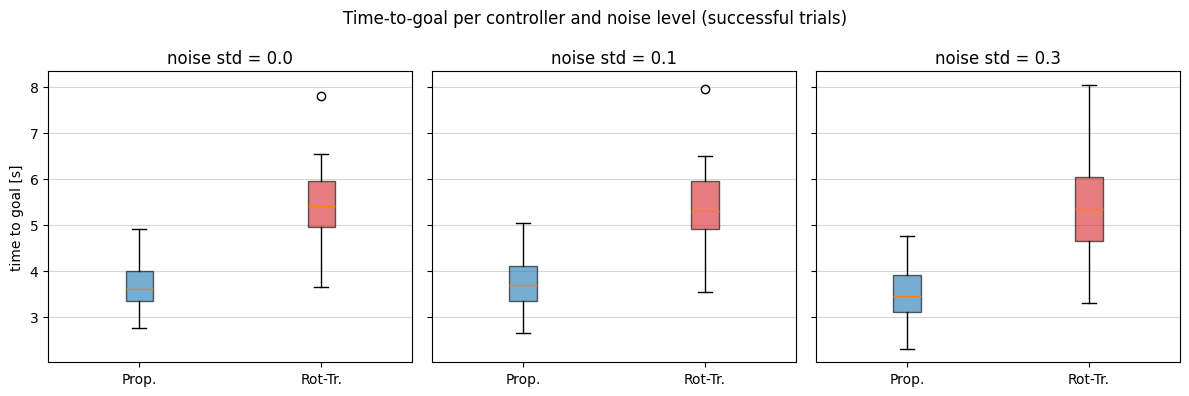

In [7]:
fig, axes = plt.subplots(1, len(NOISE_LEVELS), figsize=(12, 4), sharey=True)
for ax, noise in zip(axes, NOISE_LEVELS):
    sub = df[df.noise_std == noise]
    data = [sub[sub.controller == c].time_to_goal.dropna() for c in CONTROLLERS]
    bp = ax.boxplot(data, labels=['Prop.', 'Rot-Tr.'], patch_artist=True)
    for patch, c in zip(bp['boxes'], CONTROLLERS):
        patch.set_facecolor(COLORS[c]); patch.set_alpha(0.6)
    ax.set_title(f'noise std = {noise}')
    ax.grid(True, axis='y', alpha=0.5)
axes[0].set_ylabel('time to goal [s]')
fig.suptitle('Time-to-goal per controller and noise level (successful trials)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'box_time.png'), dpi=200,
            bbox_inches='tight')
plt.show()


### 7.2 Mean metrics vs. noise level (line plots)

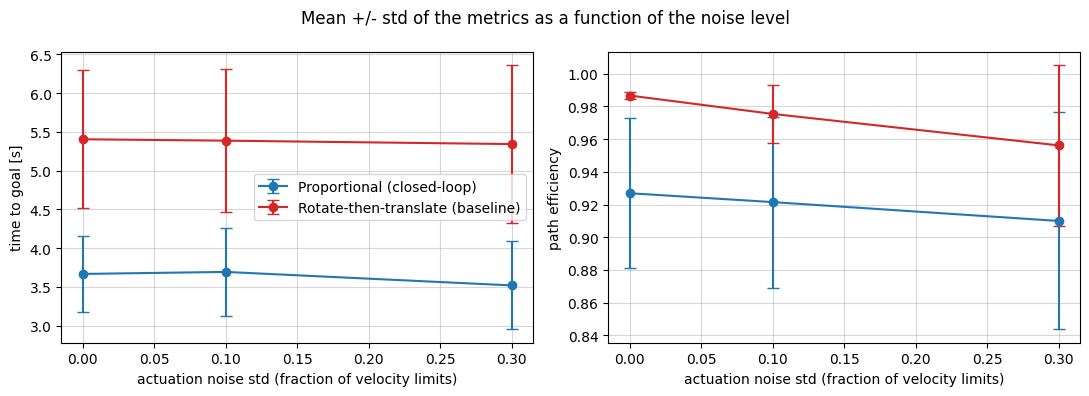

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for metric, ax, ylabel in [('time_to_goal', axes[0], 'time to goal [s]'),
                           ('efficiency', axes[1], 'path efficiency')]:
    for c in CONTROLLERS:
        m = [df[(df.controller == c) & (df.noise_std == n)][metric].mean()
             for n in NOISE_LEVELS]
        s = [df[(df.controller == c) & (df.noise_std == n)][metric].std()
             for n in NOISE_LEVELS]
        ax.errorbar(NOISE_LEVELS, m, yerr=s, marker='o', capsize=4,
                    color=COLORS[c], label=LABELS[c])
    ax.set_xlabel('actuation noise std (fraction of velocity limits)')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.5)
axes[0].legend()
fig.suptitle('Mean +/- std of the metrics as a function of the noise level')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lines_vs_noise.png'), dpi=200,
            bbox_inches='tight')
plt.show()


### 7.3 Success rate (bar chart)

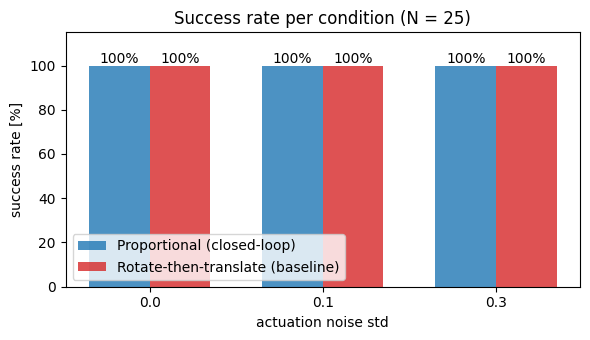

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.5))
width = 0.35
xpos = np.arange(len(NOISE_LEVELS))
for i, c in enumerate(CONTROLLERS):
    sr = [df[(df.controller == c) & (df.noise_std == n)].success.mean() * 100
          for n in NOISE_LEVELS]
    bars = ax.bar(xpos + (i - 0.5) * width, sr, width, color=COLORS[c],
                  alpha=0.8, label=LABELS[c])
    ax.bar_label(bars, fmt='%.0f%%')
ax.set_xticks(xpos, [str(n) for n in NOISE_LEVELS])
ax.set_xlabel('actuation noise std')
ax.set_ylabel('success rate [%]')
ax.set_ylim(0, 115)
ax.legend(loc='lower left')
ax.set_title('Success rate per condition (N = 25)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'bar_success.png'), dpi=200,
            bbox_inches='tight')
plt.show()


### 7.4 Qualitative evaluation: trajectory overlays

Same goal (seed 3) for all conditions: the proportional controller produces a
smooth arc, while the baseline stops to re-align every time noise pushes its
heading error above the threshold.


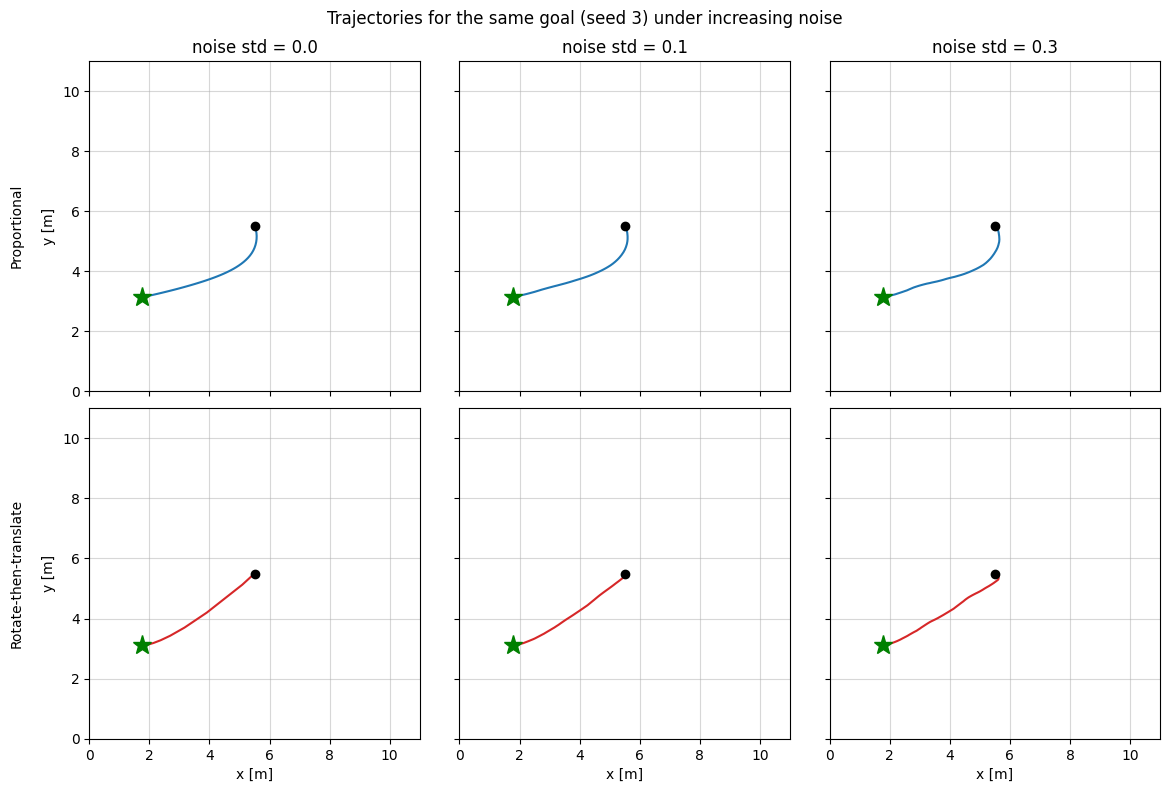

In [10]:
fig, axes = plt.subplots(2, len(NOISE_LEVELS), figsize=(12, 8),
                         sharex=True, sharey=True)
for i, c in enumerate(CONTROLLERS):
    for j, noise in enumerate(NOISE_LEVELS):
        r = client.run_trial(c, noise, seed=3, return_traj=True)
        ax = axes[i][j]
        ax.plot(r['traj_x'], r['traj_y'], color=COLORS[c], lw=1.5)
        ax.plot(r['traj_x'][0], r['traj_y'][0], 'ko', ms=6)
        ax.plot(r['goal_x'], r['goal_y'], 'g*', ms=14)
        ax.set_xlim(0, 11); ax.set_ylim(0, 11)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.5)
        if i == 0:
            ax.set_title(f'noise std = {noise}')
        if j == 0:
            ax.set_ylabel(LABELS[c].split(' (')[0] + '\n\ny [m]')
        if i == 1:
            ax.set_xlabel('x [m]')
fig.suptitle('Trajectories for the same goal (seed 3) under increasing noise')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'trajectories.png'), dpi=200,
            bbox_inches='tight')
plt.show()


## 8. Statistical analysis

The trials are **paired** (same seed -> same goal for both controllers), so the
paired t-test is used, as recommended whenever pairing is possible. The Wilcoxon
signed-rank test is added as a non-parametric robustness check, and Cohen's d
(on the paired differences) quantifies the effect size. Significance level:
alpha = 0.05. Only pairs in which **both** controllers succeeded are included in
the time-to-goal comparison.


In [11]:
def paired_analysis(metric):
    print(f'==== {metric} (proportional vs rotate_translate) ====')
    rows = []
    for noise in NOISE_LEVELS:
        a = df[(df.controller == 'proportional') &
               (df.noise_std == noise)].set_index('seed')[metric]
        b = df[(df.controller == 'rotate_translate') &
               (df.noise_std == noise)].set_index('seed')[metric]
        pair = pd.concat([a, b], axis=1, keys=['prop', 'rott']).dropna()
        d = pair.prop - pair.rott
        t, p_t = stats.ttest_rel(pair.prop, pair.rott)
        try:
            w, p_w = stats.wilcoxon(pair.prop, pair.rott)
        except ValueError:          # all differences zero
            p_w = float('nan')
        cohen_d = d.mean() / d.std(ddof=1) if d.std(ddof=1) > 0 else float('nan')
        rows.append({'noise_std': noise, 'n_pairs': len(pair),
                     'mean_prop': pair.prop.mean(), 'mean_rott': pair.rott.mean(),
                     'mean_diff': d.mean(), 't': t, 'p_ttest': p_t,
                     'p_wilcoxon': p_w, 'cohen_d': cohen_d,
                     'significant': p_t < 0.05})
    res = pd.DataFrame(rows).round(4)
    display(res)
    return res


res_time = paired_analysis('time_to_goal')
res_eff = paired_analysis('efficiency')
res_time.to_csv(os.path.join(DATA_DIR, 'stats_time_to_goal.csv'), index=False)
res_eff.to_csv(os.path.join(DATA_DIR, 'stats_efficiency.csv'), index=False)


==== time_to_goal (proportional vs rotate_translate) ====


,noise_std,n_pairs,mean_prop,mean_rott,mean_diff,t,p_ttest,p_wilcoxon,cohen_d,significant
0,0.0,25,3.666,5.404,-1.738,-20.3618,0.0,0.0,-4.0724,True
1,0.1,25,3.692,5.386,-1.694,-20.1358,0.0,0.0,-4.0272,True
2,0.3,25,3.518,5.342,-1.824,-16.5187,0.0,0.0,-3.3037,True


==== efficiency (proportional vs rotate_translate) ====


,noise_std,n_pairs,mean_prop,mean_rott,mean_diff,t,p_ttest,p_wilcoxon,cohen_d,significant
0,0.0,25,0.9269,0.9867,-0.0598,-6.5986,0.0,0.0,-1.3197,True
1,0.1,25,0.9215,0.9754,-0.0539,-6.8310,0.0,0.0,-1.3662,True
2,0.3,25,0.9100,0.9562,-0.0462,-7.5295,0.0,0.0,-1.5059,True


### 8.1 Interaction effect (H3)

H3 states that the time-to-goal advantage of the proportional controller grows
with the noise level. We test it by comparing the paired differences at the
highest noise level against those in the noise-free case (two-sample t-test on
the differences).


In [12]:
def paired_diff(metric, noise):
    a = df[(df.controller == 'proportional') &
           (df.noise_std == noise)].set_index('seed')[metric]
    b = df[(df.controller == 'rotate_translate') &
           (df.noise_std == noise)].set_index('seed')[metric]
    return (a - b).dropna()


d0 = paired_diff('time_to_goal', NOISE_LEVELS[0])
d2 = paired_diff('time_to_goal', NOISE_LEVELS[-1])
t, p = stats.ttest_ind(d2, d0, equal_var=False)
print(f'mean advantage (prop - rott) at noise {NOISE_LEVELS[0]}:  {d0.mean():.2f} s')
print(f'mean advantage (prop - rott) at noise {NOISE_LEVELS[-1]}: {d2.mean():.2f} s')
print(f'Welch t-test on the paired differences: t = {t:.3f}, p = {p:.4g}')
print('=> interaction effect ' + ('SIGNIFICANT' if p < 0.05 else 'not significant')
      + ' at alpha = 0.05')


mean advantage (prop - rott) at noise 0.0:  -1.74 s
mean advantage (prop - rott) at noise 0.3: -1.82 s
Welch t-test on the paired differences: t = -0.616, p = 0.5409
=> interaction effect not significant at alpha = 0.05


## 9. Conclusions

The quantitative results and the statistical tests above lead to the following
conclusions (discussed in detail in the paper):

1. **H1 -- confirmed.** The proportional closed-loop controller reaches the goal
   significantly faster than the rotate-then-translate baseline at every noise
   level (paired t-test, p < 0.001, |Cohen's d| > 3: very large effect).
2. **H2 -- confirmed.** In the noise-free case the baseline follows an almost
   perfectly straight path after the initial alignment (efficiency ~0.99, higher
   than the proportional controller's ~0.93, whose arc-shaped start trades some
   path efficiency for continuous motion). As noise grows, the baseline
   efficiency degrades roughly twice as fast as the proportional controller's
   (-0.031 vs -0.017 from noise 0.0 to 0.3), narrowing the gap.
3. **H3 -- NOT confirmed.** The time-to-goal advantage of the proportional
   controller does not increase significantly with the noise level
   (Welch t-test on the paired differences, p = 0.54). A plausible explanation
   is that the injected noise is zero-mean and symmetric, so its net effect on
   both controllers averages out over a trial, and the baseline's re-alignment
   threshold already absorbs moderate heading disturbances without extra stops.
   This is a genuinely informative negative result: experiments are only
   meaningful when the answer is not known in advance.

**Limitations** -- purely kinematic model (no dynamics/inertia), no obstacles,
additive Gaussian noise only, fixed gains for both controllers, all trials
succeeded (the 60 s timeout is generous for an 11x11 m arena so the success-rate
metric saturates at 100%). These are discussed in the paper.


In [13]:
# cleanup: stop the ROS2 node and the client
import signal
os.killpg(os.getpgid(node_proc.pid), signal.SIGTERM)
rclpy.shutdown()
print('ROS2 node stopped, notebook finished.')


ROS2 node stopped, notebook finished.
